<a href="https://colab.research.google.com/github/Jinn-M4/PID-based-Cruise-Control-System-Simulation/blob/main/PID.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PID-based Cruise Control

## 라이브러리

In [1]:
import matplotlib.pyplot as plt

## 시뮬레이션 설정

In [2]:
dt = 0.1
time = 0
end_time = 20

target_speed = 60.0
speed = 0.0

2. PID 파라미터

In [3]:
Kp = 0.6
Ki = 0.2
Kd = 0.05

integral = 0.0
prev_error = 0.0

3. 데이터 저장

In [4]:
time_list = []
speed_list = []
error_list = []
target_list = []

4. 시뮬레이션 루프

In [5]:
while time <= end_time:

    error = target_speed - speed

    # PID 계산
    integral += error * dt
    derivative = (error - prev_error) / dt
    throttle = Kp * error + Ki * integral + Kd * derivative

    # throttle 제한
    throttle = max(0, min(throttle, 100))

    # Anti-windup
    integral = max(min(integral, 100), -100)

    # 차량 모델
    resistance = 0.1 * speed

    # disturbance (5초 이후)
    if time > 5:
        disturbance = -2.0
    else:
        disturbance = 0.0

    acceleration = throttle - resistance + disturbance

    speed += acceleration * dt

    # 데이터 저장
    time_list.append(time)
    speed_list.append(speed)
    error_list.append(error)
    target_list.append(target_speed)

    prev_error = error
    time += dt

5. Speed 그래프

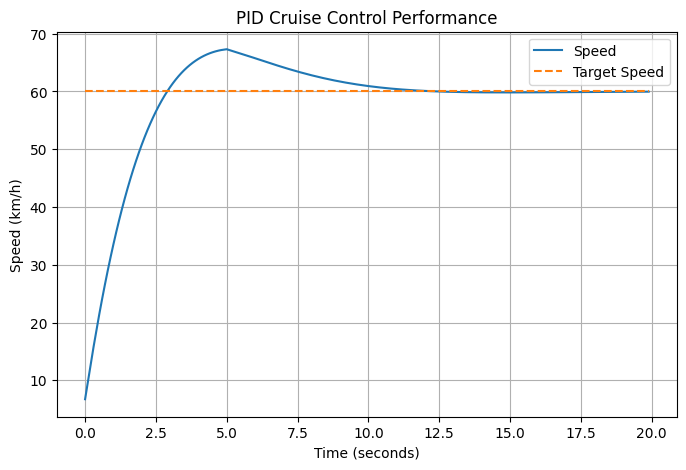

In [6]:
plt.figure(figsize=(8,5))

plt.plot(time_list, speed_list, label="Speed")
plt.plot(time_list, target_list, linestyle='--', label="Target Speed")

plt.xlabel("Time (seconds)")
plt.ylabel("Speed (km/h)")
plt.title("PID Cruise Control Performance")
plt.legend()
plt.grid()

plt.savefig("pid_speed.png", dpi=300)
plt.show()

6. Error 그래프

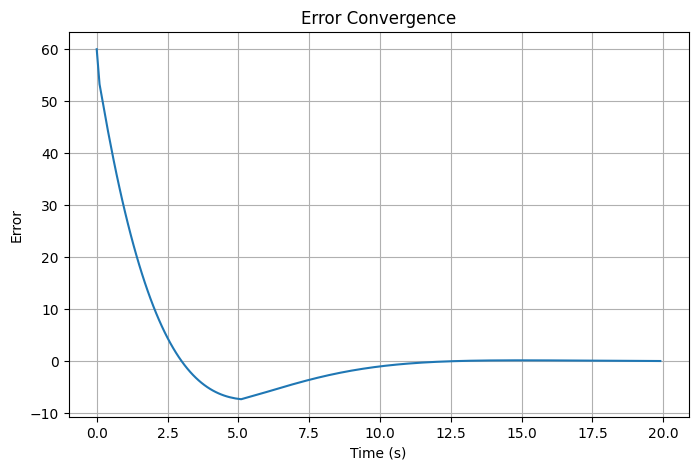

In [7]:
plt.figure(figsize=(8,5))

plt.plot(time_list, error_list)

plt.xlabel("Time (s)")
plt.ylabel("Error")
plt.title("Error Convergence")
plt.grid()

plt.savefig("pid_error.png", dpi=300)
plt.show()